# Feature Engineering for Logistic Regression

## Overview
This notebook documents the feature engineering process applied to the particle dataset in preparation for downstream logistic regression modeling.

The objective is to construct features that:
- Improve linear separability between classes
- Capture meaningful elemental relationships
- Align with statistical assumptions of logistic regression

All transformations are informed by prior exploratory data analysis (EDA), including UMAP results and domain knowledge in forensic particle classification.

## Feature Engineering Design Considerations

Feature construction was revised to better support downstream logistic regression modeling while reducing features that directly reconstruct the class label.

### 1. Balance predictive power and generalizability
Some elemental features, especially Pb, Ba, and Sb, are highly informative because they are closely tied to the forensic definition of GSR. Those features are still useful for a baseline model, but they should be separated from stricter engineered feature sets.

### 2. Support linear modeling
Logistic regression benefits from transformations that reduce skew and approximate linear relationships with the log-odds. For that reason, this notebook emphasizes:
- log-transformed elemental intensities
- ratio features
- interaction terms
- normalized composition features

### 3. Avoid direct label proxies
The previous version included `gsr_count`, which acted as a shortcut to the label. That feature has been removed and replaced with more general composition-based features.

### 4. Create multiple feature tiers
This notebook now creates engineered features once, then defines several candidate feature sets that can be reused in modeling notebooks:
- `full_features`
- `engineered_only_features`
- `extreme_drop_features`

This makes model comparison more consistent and easier to explain in the final report.


## Data Loading

The processed particle dataset is loaded from the project data directory.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib as mpl
import matplotlib.pyplot as plt

from matplotlib.colors import LinearSegmentedColormap, TwoSlopeNorm
from matplotlib.ticker import StrMethodFormatter, FuncFormatter

df = pd.read_parquet("../../../data/processed/particle_labeled.parquet")

print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

df.head()

Shape: (2801667, 95)

Columns:
['stub_id', 'particle_id', 'relevance_class', 'ac', 'ag', 'al', 'ar', 'as', 'at', 'au', 'b', 'ba', 'bi', 'br', 'ca', 'cd', 'ce', 'cl', 'co', 'cr', 'cs', 'cu', 'dy', 'er', 'eu', 'f', 'fe', 'fr', 'ga', 'gd', 'ge', 'hf', 'hg', 'ho', 'i', 'in', 'ir', 'k', 'kr', 'la', 'lu', 'mg', 'mn', 'mo', 'n', 'na', 'nb', 'nd', 'ne', 'ni', 'np', 'o', 'os', 'p', 'pa', 'pb', 'pd', 'pm', 'po', 'pr', 'pt', 'pu', 'ra', 'rb', 're', 'rh', 'rn', 'ru', 's', 'sb', 'sc', 'se', 'si', 'sm', 'sn', 'sr', 'ta', 'tb', 'tc', 'te', 'th', 'ti', 'tl', 'tm', 'u', 'v', 'w', 'xe', 'y', 'yb', 'zn', 'zr', 'merged_relevance_class', 'final_class', 'label']


,stub_id,particle_id,relevance_class,ac,ag,al,ar,as,at,au,...,v,w,xe,y,yb,zn,zr,merged_relevance_class,final_class,label
0,22,1454,PbSb,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,PbSb,PbSb,GSR
1,22,1274,PbSbBa,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,PbSbBa,PbBaSb,GSR
2,22,275,PbSbBa,0.0,0.0,0.751013,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,PbSbBa,PbBaSb,GSR
3,22,714,PbSbBa,0.0,0.0,0.824510,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,PbSbBa,PbBaSb,GSR
4,22,2887,PbSb,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,PbSb,PbSb,GSR


## Feature Engineering Approach

The following transformations are applied:

- Log transformations of selected elemental features
- Log-transformed elemental ratios among Pb, Ba, and Sb
- Cross-group ratios between GSR-related and confounder elements
- Interaction terms for important element pairs
- Composition features normalized by total elemental mass
- A general element-diversity feature

The notebook then defines multiple feature tiers for downstream logistic regression modeling so that direct elemental signal can be compared against stricter engineered representations.


In [2]:
def engineer_features_logistic(df):
    df = df.copy()
    eps = 1e-6

    # --------------------------------------------------
    # 0. Identify core element groups used in engineering
    # --------------------------------------------------
    direct_elements = [col for col in ["pb", "ba", "sb"] if col in df.columns]
    confounder_elements = [col for col in ["zn", "cu", "ti"] if col in df.columns]

    # Numeric elemental columns that are not identifiers or labels
    non_feature_cols = {
        "stub_id", "particle_id", "relevance_class", "merged_relevance_class",
        "final_class", "label", "target"
    }
    element_cols = [
        col for col in df.select_dtypes(include=[np.number]).columns
        if col not in non_feature_cols
    ]
    # Store all new features here first
    new_features = {}

    # --------------------------------------------------
    # 1. Log transformations
    # --------------------------------------------------
    for col in ["pb", "ba", "sb", "zn", "cu", "ti"]:
        if col in df.columns:
            new_features[f"log_{col}"] = np.log1p(df[col])

    # --------------------------------------------------
    # 2. Ratios among core GSR elements
    # --------------------------------------------------
    if all(col in df.columns for col in ["pb", "ba"]):
        new_features["log_pb_ba_ratio"] = np.log1p(df["pb"] / (df["ba"] + eps))

    if all(col in df.columns for col in ["pb", "sb"]):
        new_features["log_pb_sb_ratio"] = np.log1p(df["pb"] / (df["sb"] + eps))

    if all(col in df.columns for col in ["ba", "sb"]):
        new_features["log_ba_sb_ratio"] = np.log1p(df["ba"] / (df["sb"] + eps))

    # --------------------------------------------------
    # 3. Ratios vs confounders
    # --------------------------------------------------
    if all(col in df.columns for col in ["pb", "zn"]):
        new_features["log_pb_zn_ratio"] = np.log1p(df["pb"] / (df["zn"] + eps))

    if all(col in df.columns for col in ["sb", "cu"]):
        new_features["log_sb_cu_ratio"] = np.log1p(df["sb"] / (df["cu"] + eps))

    if all(col in df.columns for col in ["ba", "ti"]):
        new_features["log_ba_ti_ratio"] = np.log1p(df["ba"] / (df["ti"] + eps))

    # -----------------------------
    # 4. Domain summary features
    # -----------------------------
    if direct_elements:
        gsr_sum = df[direct_elements].sum(axis=1)
    else:
        gsr_sum = pd.Series(0, index=df.index)

    if confounder_elements:
        conf_sum = df[confounder_elements].sum(axis=1)
    else:
        conf_sum = pd.Series(0, index=df.index)

    if element_cols:
        total_mass = df[element_cols].sum(axis=1) + eps
    else:
        total_mass = pd.Series(eps, index=df.index)

    if direct_elements and confounder_elements:
        new_features["log_gsr_over_confounders"] = np.log1p(gsr_sum / (conf_sum + eps))

    # Composition / percentage features
    for col in element_cols:
        new_features[f"{col}_pct"] = df[col] / total_mass

    # -----------------------------
    # 5. Interaction terms
    # -----------------------------
    if all(col in df.columns for col in ["pb", "sb"]):
        new_features["pb_sb_interaction"] = df["pb"] * df["sb"]

    if all(col in df.columns for col in ["ba", "sb"]):
        new_features["ba_sb_interaction"] = df["ba"] * df["sb"]

    if all(col in df.columns for col in ["pb", "ba"]):
        new_features["pb_ba_interaction"] = df["pb"] * df["ba"]

    # -----------------------------
    # 6. Diversity / complexity
    # -----------------------------
    if element_cols:
        new_features["element_diversity"] = (df[element_cols] > 0).sum(axis=1)

    # -----------------------------
    # 7. Combine all at once
    # -----------------------------
    feature_df = pd.DataFrame(new_features, index=df.index)
    df_out = pd.concat([df, feature_df], axis=1)

    return df_out

## Apply Feature Engineering

The feature engineering function is applied to the dataset to generate the transformed feature set.

In [3]:
df_fe = engineer_features_logistic(df)

print(df_fe.shape)
df_fe.head()

(2801667, 201)


,stub_id,particle_id,relevance_class,ac,ag,al,ar,as,at,au,...,w_pct,xe_pct,y_pct,yb_pct,zn_pct,zr_pct,pb_sb_interaction,ba_sb_interaction,pb_ba_interaction,element_diversity
0,22,1454,PbSb,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,661.867116,0.000000,0.000000,5
1,22,1274,PbSbBa,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,33.296388,27.956082,389.305347,7
2,22,275,PbSbBa,0.0,0.0,0.751013,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,202.132405,77.448799,190.695496,9
3,22,714,PbSbBa,0.0,0.0,0.824510,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,157.126956,94.747664,222.243029,8
4,22,2887,PbSb,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,228.529209,0.000000,0.000000,6


## Feature Set Definitions for Logistic Regression

Multiple feature tiers are defined so that downstream models can compare performance under different levels of direct elemental signal.

- **Full feature set**: includes direct Pb, Ba, and Sb information along with engineered ratios
- **Engineered-only feature set**: keeps engineered ratio and interaction features while removing direct percentage and count shortcuts
- **Extreme drop feature set**: removes any feature containing Pb, Ba, or Sb so the model must rely on remaining chemistry

These feature sets are defined here for reuse in the logistic regression notebook.


In [4]:
# -----------------------------
# Feature set definitions
# These help with later feature selection/testing
# -----------------------------
full_features = [
    col for col in [
        "log_pb", "log_ba", "log_sb",
        "log_pb_ba_ratio", "log_pb_sb_ratio", "log_ba_sb_ratio",
        "log_pb_zn_ratio", "log_sb_cu_ratio", "log_ba_ti_ratio",
        "log_gsr_over_confounders",
        "pb_pct", "ba_pct", "sb_pct",
        "pb_sb_interaction", "ba_sb_interaction", "pb_ba_interaction",
        "element_diversity"
    ]
    if col in df_fe.columns
]

engineered_only_features = [
    col for col in [
        "log_pb_ba_ratio", "log_pb_sb_ratio", "log_ba_sb_ratio",
        "log_pb_zn_ratio", "log_sb_cu_ratio", "log_ba_ti_ratio",
        "pb_sb_interaction", "ba_sb_interaction", "pb_ba_interaction",
        "element_diversity"
    ]
    if col in df_fe.columns
]

drop_keywords = ["pb", "ba", "sb", "gsr"]
extreme_drop_features = [
    col for col in df_fe.select_dtypes(include=[np.number]).columns
    if col not in ["stub_id", "particle_id", "target"]
    and col != "label"
    and not any(keyword in col.lower() for keyword in drop_keywords)
]

feature_sets = {
    "full_features": full_features,
    "engineered_only_features": engineered_only_features,
    "extreme_drop_features": extreme_drop_features
}

for name, cols in feature_sets.items():
    print(f"{name}: {len(cols)} features")

full_features: 17 features
engineered_only_features: 10 features
extreme_drop_features: 176 features


## Feature Validation Checks

The checks below help confirm that the engineered dataset contains the expected feature groups and that obvious shortcut features have been removed from the stricter feature sets.


In [5]:
# Sanity checks for feature set definitions

print("Forbidden columns in engineered_only_features:")
print([col for col in engineered_only_features if col in ["gsr_count", "pb_pct", "ba_pct", "sb_pct"]])

print("\nForbidden keywords in extreme_drop_features:")
print([col for col in extreme_drop_features if any(k in col.lower() for k in ["pb", "ba", "sb", "gsr"])])

# -----------------------------
# Target distribution / class imbalance checks
# -----------------------------
if "label" in df_fe.columns:
    print("Label counts:")
    print(df_fe["label"].value_counts(dropna=False))
    print()

    print("Label proportions:")
    print(df_fe["label"].value_counts(normalize=True, dropna=False))

# -----------------------------
# Leakage checks
# Keep stub_id for future grouped train/test split
# -----------------------------
if "stub_id" in df_fe.columns and "label" in df_fe.columns:
    stub_summary = (
        df_fe.groupby("stub_id")["label"]
        .agg(["count", "nunique"])
        .sort_values("count", ascending=False)
    )

    print("Stub-level summary:")
    print(stub_summary.head())

    print("\nNumber of unique stub_id values:")
    print(df_fe["stub_id"].nunique())

# -----------------------------
# Missingness check for engineered features
# -----------------------------
engineered_cols = [col for col in df_fe.columns if col not in df.columns]

missing_summary = (
    df_fe[engineered_cols]
    .isna()
    .mean()
    .sort_values(ascending=False)
)

print("Missingness in engineered features:")
print(missing_summary.head(20))

Forbidden columns in engineered_only_features:
[]

Forbidden keywords in extreme_drop_features:
[]
Label counts:
label
Non_GSR      1216039
GSR          1078946
Ambiguous     506682
Name: count, dtype: int64

Label proportions:
label
Non_GSR      0.434041
GSR          0.385109
Ambiguous    0.180850
Name: proportion, dtype: float64
Stub-level summary:
         count  nunique
stub_id                
3959     15155        3
1322     10095        3
773       8789        3
374       8558        2
2760      7515        3

Number of unique stub_id values:
3919
Missingness in engineered features:
log_pb                      0.0
log_ba                      0.0
log_sb                      0.0
log_zn                      0.0
log_cu                      0.0
log_ti                      0.0
log_pb_ba_ratio             0.0
log_pb_sb_ratio             0.0
log_ba_sb_ratio             0.0
log_pb_zn_ratio             0.0
log_sb_cu_ratio             0.0
log_ba_ti_ratio             0.0
log_gsr_over_confoun

In [6]:
plot_n = min(100000, len(df_fe))

if len(df_fe) > plot_n:
    plot_df = df_fe.sample(plot_n, random_state=42).copy()
else:
    plot_df = df_fe.copy()

print("Plot sample shape:", plot_df.shape)

Plot sample shape: (100000, 201)


## Before vs After Log Transformation

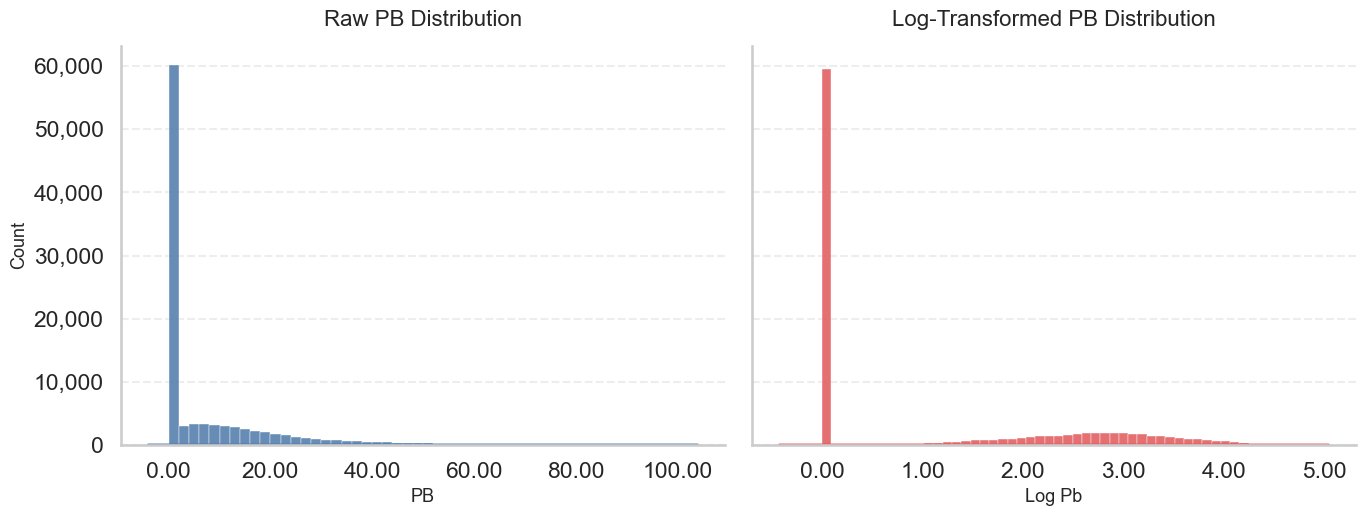

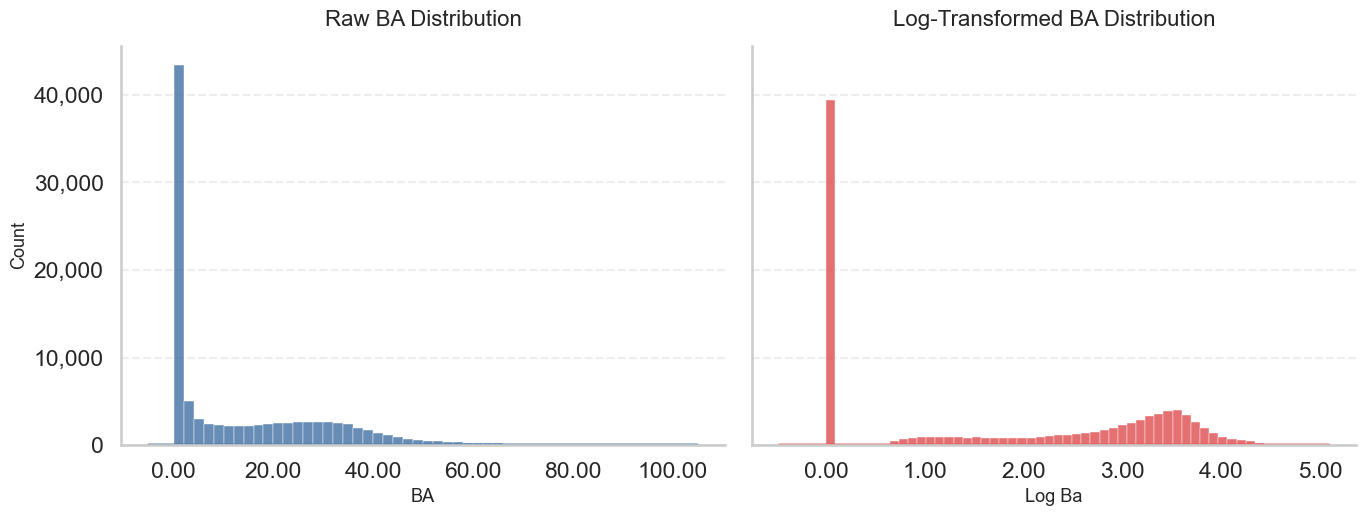

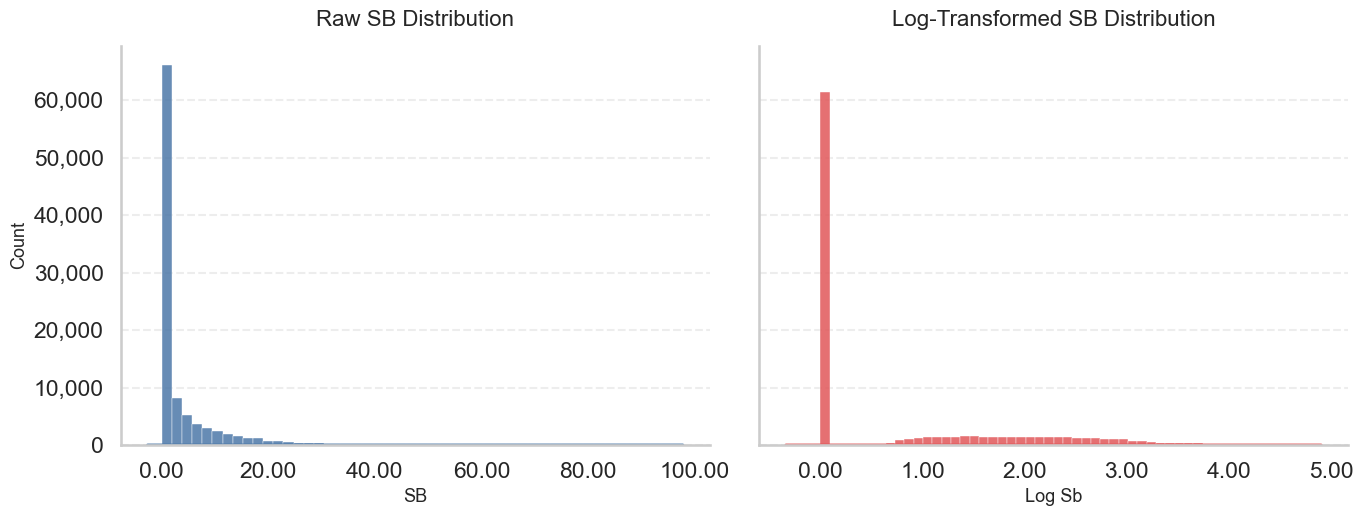

In [7]:
sns.set_theme(style="whitegrid", context="talk")

pairs = [
    ("pb", "log_pb"),
    ("ba", "log_ba"),
    ("sb", "log_sb"),
]

raw_color = "#4C78A8"
log_color = "#E15759"

for raw_col, log_col in pairs:
    if raw_col in plot_df.columns and log_col in plot_df.columns:
        fig, axes = plt.subplots(1, 2, figsize=(14, 5.5), sharey=True, facecolor="white")

        raw_vals = plot_df[raw_col].dropna()
        log_vals = plot_df[log_col].dropna()

        sns.histplot(
            raw_vals,
            bins=50,
            stat="count",
            color=raw_color,
            alpha=0.85,
            edgecolor="white",
            linewidth=0.3,
            ax=axes[0]
        )
        sns.kdeplot(raw_vals, color=raw_color, linewidth=2.2, ax=axes[0])

        sns.histplot(
            log_vals,
            bins=50,
            stat="count",
            color=log_color,
            alpha=0.85,
            edgecolor="white",
            linewidth=0.3,
            ax=axes[1]
        )
        sns.kdeplot(log_vals, color=log_color, linewidth=2.2, ax=axes[1])

        axes[0].set_title(f"Raw {raw_col.upper()} Distribution", fontsize=16, pad=14)
        axes[0].set_xlabel(raw_col.upper(), fontsize=13)
        axes[0].set_ylabel("Count", fontsize=13)

        axes[1].set_title(f"Log-Transformed {raw_col.upper()} Distribution", fontsize=16, pad=14)
        axes[1].set_xlabel(log_col.replace("_", " ").title(), fontsize=13)
        axes[1].set_ylabel("")

        # Format y-axis with commas
        axes[0].yaxis.set_major_formatter(StrMethodFormatter("{x:,.0f}"))
        axes[1].yaxis.set_major_formatter(StrMethodFormatter("{x:,.0f}"))

        # Format x-axes appropriately
        if raw_vals.max() >= 1000:
            axes[0].xaxis.set_major_formatter(StrMethodFormatter("{x:,.0f}"))
        else:
            axes[0].xaxis.set_major_formatter(FuncFormatter(lambda x, pos: f"{x:,.2f}"))

        axes[1].xaxis.set_major_formatter(FuncFormatter(lambda x, pos: f"{x:,.2f}"))

        for ax in axes:
            ax.spines["top"].set_visible(False)
            ax.spines["right"].set_visible(False)
            ax.grid(axis="y", linestyle="--", alpha=0.35)
            ax.grid(axis="x", visible=False)

        plt.tight_layout()
        plt.show()

## Boxplots of Engineered Ratio Features by Class

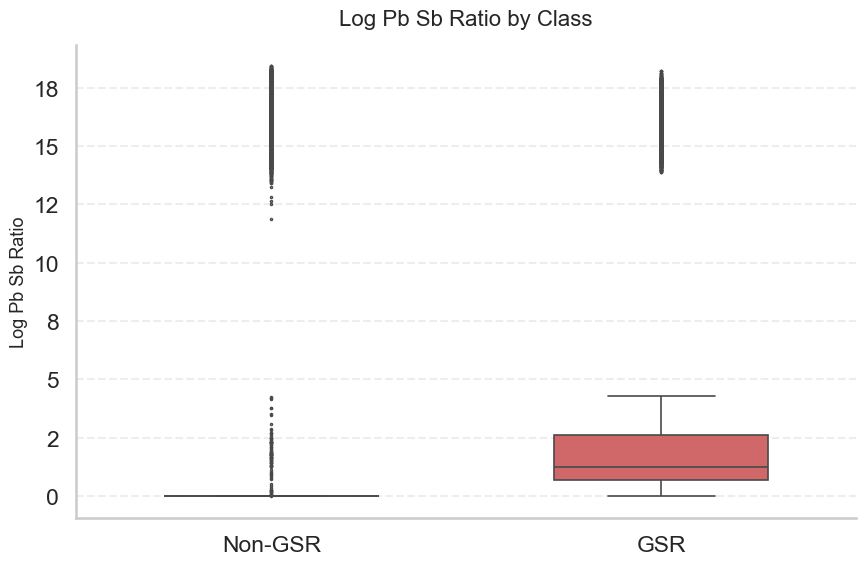

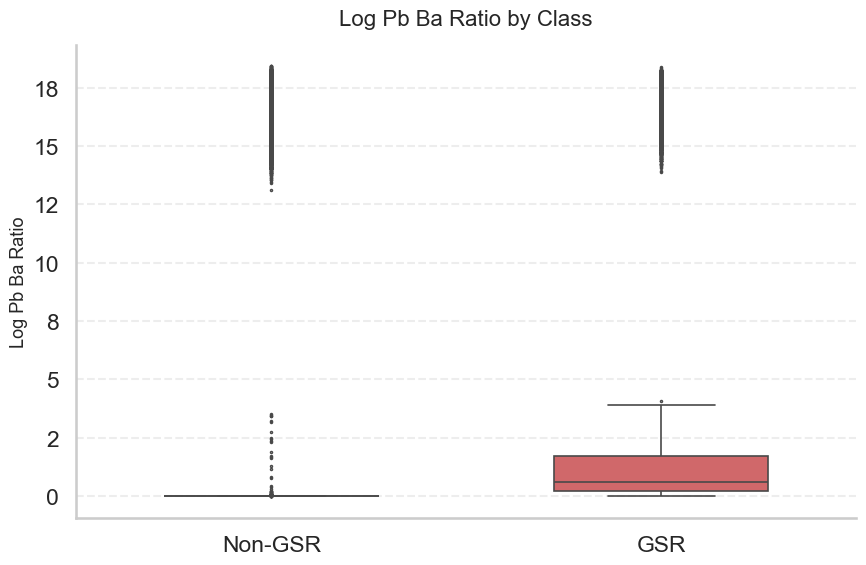

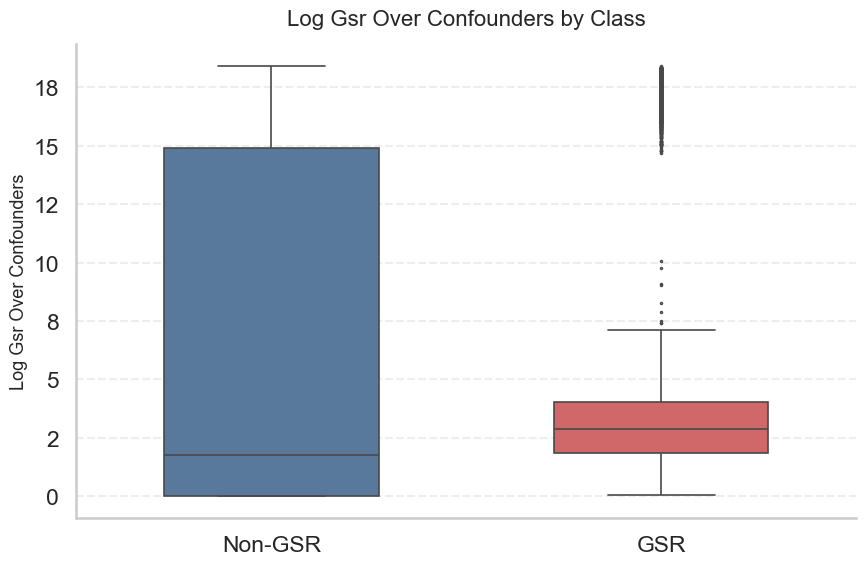

In [8]:
sns.set_theme(style="whitegrid", context="talk")

ratio_features_to_plot = [
    "log_pb_sb_ratio",
    "log_pb_ba_ratio",
    "log_gsr_over_confounders"
]

# Professional class colors
class_palette = {
    "Non-GSR": "#4C78A8",   # muted blue
    "GSR": "#E15759"        # muted red
}

for feature in ratio_features_to_plot:
    if feature in plot_df.columns and "label" in plot_df.columns:
        plot_box = plot_df.copy()

        # Standardize class labels for plotting
        plot_box["plot_label"] = np.where(
            plot_box["label"].astype(str).str.upper().isin(["GSR", "1"]),
            "GSR",
            "Non-GSR"
        )

        fig, ax = plt.subplots(figsize=(9, 6), facecolor="white")

        sns.boxplot(
            data=plot_box,
            x="plot_label",
            y=feature,
            hue="plot_label",
            palette=class_palette,
            dodge=False,
            width=0.55,
            linewidth=1.2,
            fliersize=1.5,
            ax=ax
        )

        # Remove duplicate legend created by hue
        if ax.legend_ is not None:
            ax.legend_.remove()

        # Formatting
        ax.set_title(f"{feature.replace('_', ' ').title()} by Class", fontsize=16, pad=14)
        ax.set_xlabel("")
        ax.set_ylabel(feature.replace("_", " ").title(), fontsize=13)

        # Thousands separators
        ax.yaxis.set_major_formatter(StrMethodFormatter("{x:,.0f}"))

        # Clean spines / grid
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        ax.grid(axis="y", linestyle="--", alpha=0.35)
        ax.grid(axis="x", visible=False)

        plt.tight_layout()
        plt.show()

## Distribution Comparisons by Class

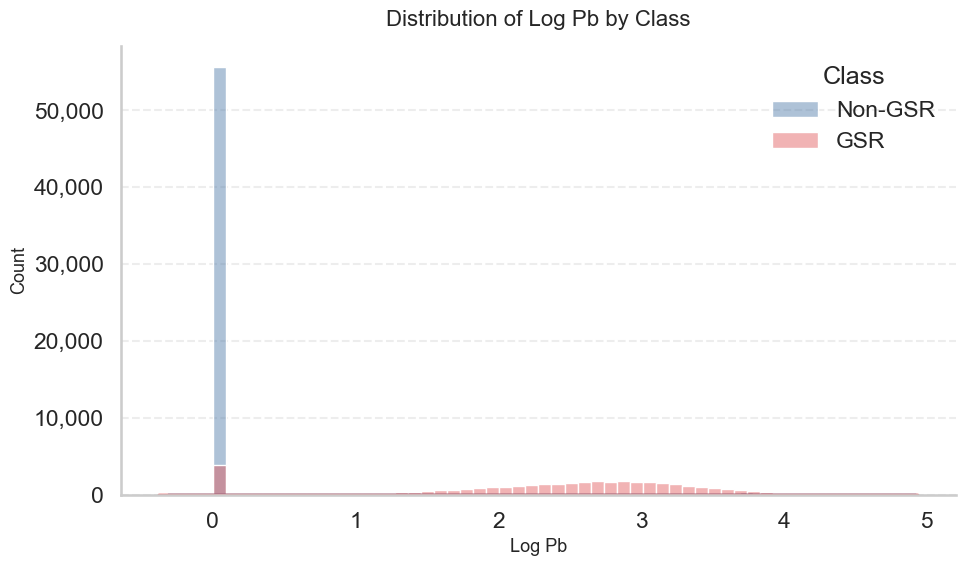

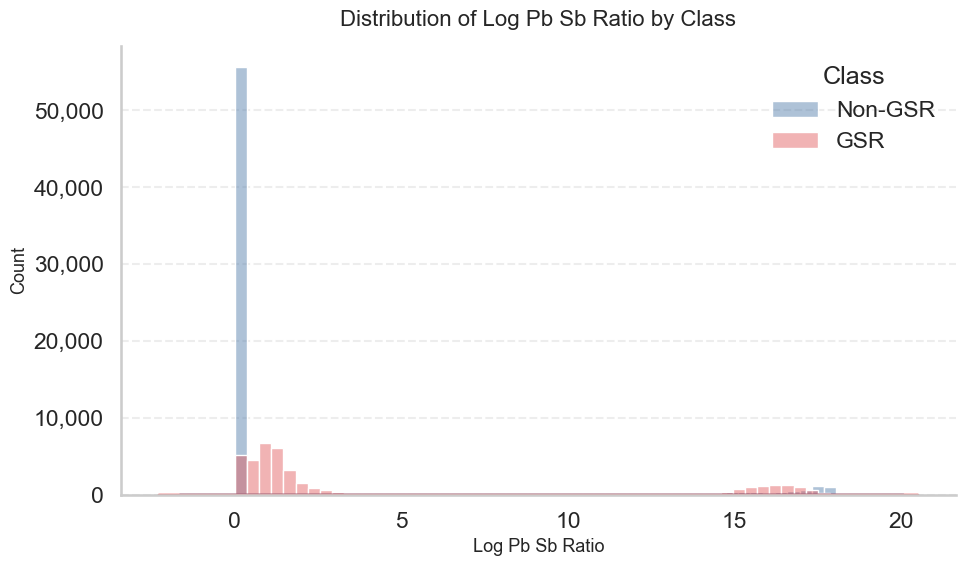

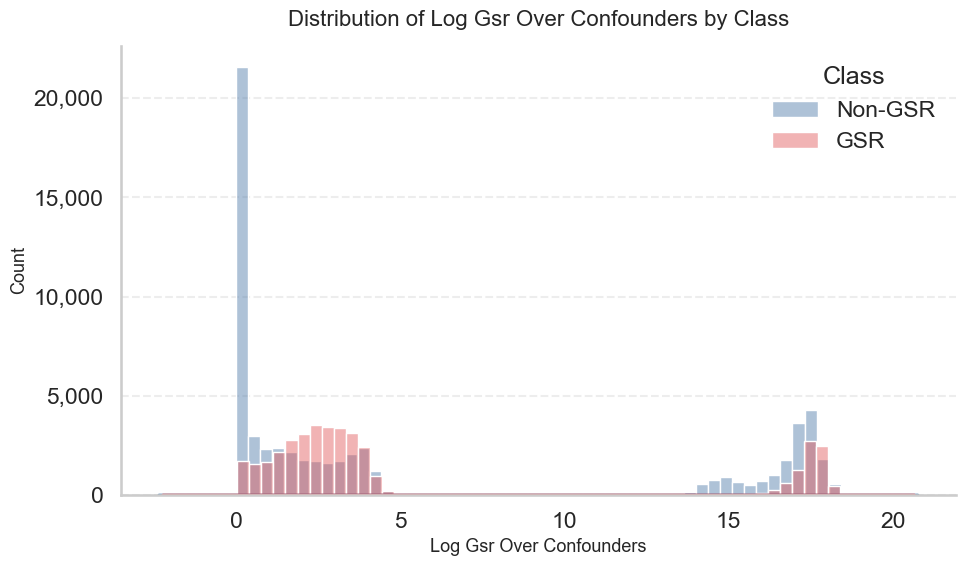

In [9]:

sns.set_theme(style="whitegrid", context="talk")

distribution_features = [
    "log_pb",
    "log_pb_sb_ratio",
    "log_gsr_over_confounders"
]

class_palette = {
    "Non-GSR": "#4C78A8",   # muted blue
    "GSR": "#E15759"        # muted red
}

for feature in distribution_features:
    if feature in plot_df.columns and "label" in plot_df.columns:
        plot_dist = plot_df.copy()

        plot_dist["plot_label"] = np.where(
            plot_dist["label"].astype(str).str.upper().isin(["GSR", "1"]),
            "GSR",
            "Non-GSR"
        )

        fig, ax = plt.subplots(figsize=(10, 6), facecolor="white")

        sns.histplot(
            data=plot_dist[plot_dist["plot_label"] == "Non-GSR"],
            x=feature,
            bins=50,
            stat="count",
            color=class_palette["Non-GSR"],
            alpha=0.45,
            edgecolor=None,
            label="Non-GSR",
            ax=ax
        )

        sns.histplot(
            data=plot_dist[plot_dist["plot_label"] == "GSR"],
            x=feature,
            bins=50,
            stat="count",
            color=class_palette["GSR"],
            alpha=0.45,
            edgecolor=None,
            label="GSR",
            ax=ax
        )

        # Optional density overlays for a more polished look
        sns.kdeplot(
            data=plot_dist[plot_dist["plot_label"] == "Non-GSR"],
            x=feature,
            color=class_palette["Non-GSR"],
            linewidth=2,
            ax=ax
        )

        sns.kdeplot(
            data=plot_dist[plot_dist["plot_label"] == "GSR"],
            x=feature,
            color=class_palette["GSR"],
            linewidth=2,
            ax=ax
        )

        ax.set_title(f"Distribution of {feature.replace('_', ' ').title()} by Class", fontsize=16, pad=14)
        ax.set_xlabel(feature.replace("_", " ").title(), fontsize=13)
        ax.set_ylabel("Count", fontsize=13)

        # Thousands separators
        ax.xaxis.set_major_formatter(StrMethodFormatter("{x:,.0f}"))
        ax.yaxis.set_major_formatter(StrMethodFormatter("{x:,.0f}"))

        # Clean styling
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        ax.grid(axis="y", linestyle="--", alpha=0.35)
        ax.grid(axis="x", visible=False)
        ax.legend(frameon=False, title="Class")

        plt.tight_layout()
        plt.show()

## Correlation Heatmap for Engineered Features

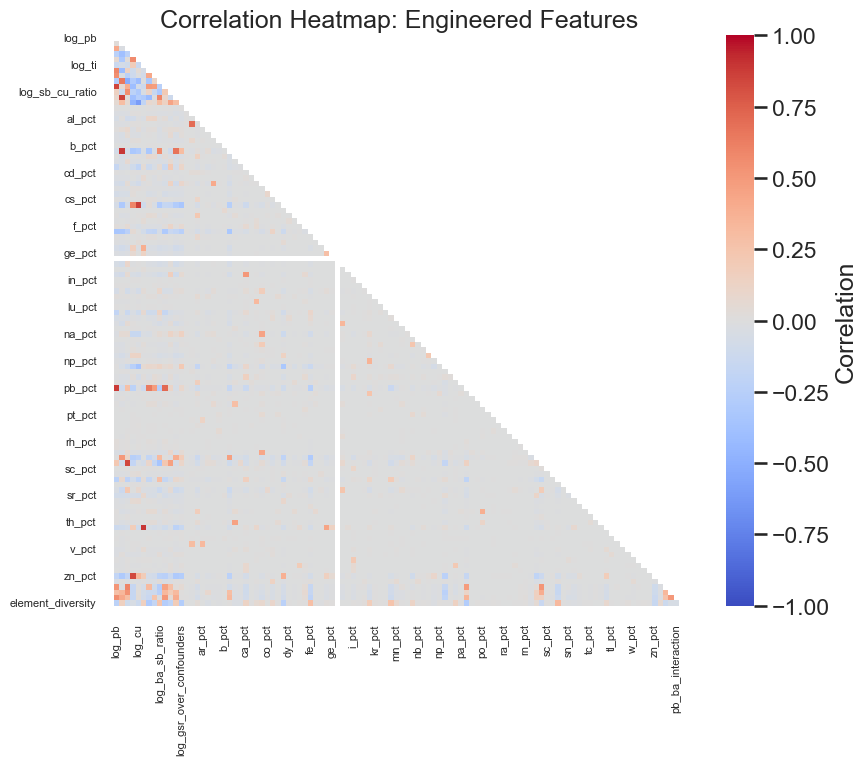

In [10]:
engineered_cols = [col for col in df_fe.columns if col not in df.columns]
engineered_cols_plot = [col for col in engineered_cols if col in plot_df.columns]
engineered_numeric = plot_df[engineered_cols_plot].select_dtypes(include=[np.number])

# Correlation matrix
corr = engineered_numeric.corr()

# Optional: mask upper triangle (keeps it clean, like your NN figure)
mask = np.triu(np.ones_like(corr, dtype=bool))

sns.set_style("white")
plt.figure(figsize=(10, 8))

sns.heatmap(
    corr,
    mask=mask,
    cmap="coolwarm",   # keep your preferred palette
    vmin=-1,
    vmax=1,
    center=0,
    square=True,
    cbar_kws={"label": "Correlation"}
)

plt.title("Correlation Heatmap: Engineered Features")
plt.xticks(rotation=90, fontsize=8)
plt.yticks(fontsize=8)

plt.tight_layout()
plt.show()

## Distribution of Elemental Percentage Features (Pb, Ba, Sb)

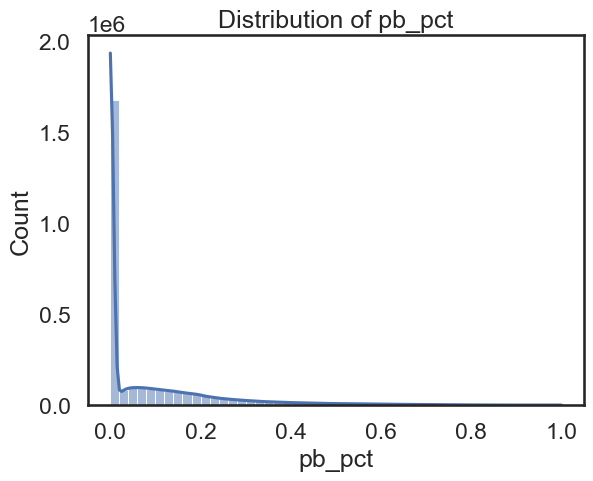

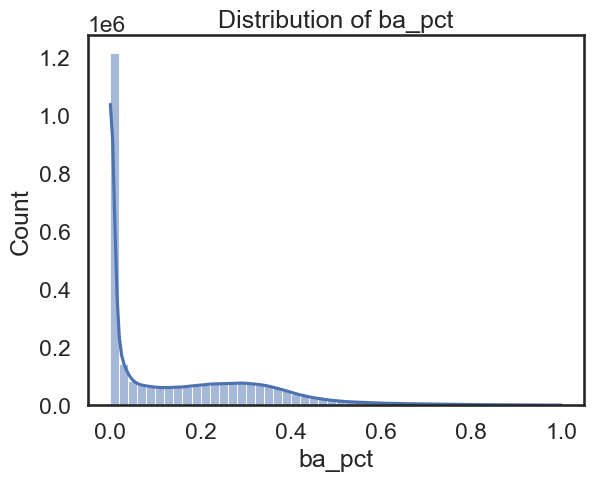

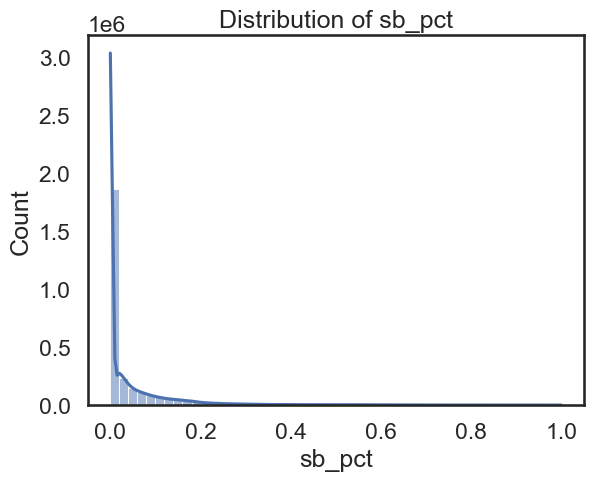

In [13]:
features = ["pb_pct", "ba_pct", "sb_pct"]

for col in features:
    plt.figure()
    sns.histplot(df_fe[col], bins=50, kde=True)
    plt.title(f"Distribution of {col}")
    plt.show()

## Correlation with Target

In [11]:
# Create numeric target from label if target does not exist
if "target" not in df_fe.columns and "label" in df_fe.columns:
    df_fe["target"] = df_fe["label"].map({"Non_GSR": 0, "GSR": 1, "non_gsr": 0, "gsr": 1})

print(df_fe[["label", "target"]].head())
print(df_fe["target"].value_counts(dropna=False))

  label  target
0   GSR     1.0
1   GSR     1.0
2   GSR     1.0
3   GSR     1.0
4   GSR     1.0
target
0.0    1216039
1.0    1078946
NaN     506682
Name: count, dtype: int64


## Save Engineered Dataset

The engineered dataset is saved for downstream modeling. The notebook also retains reusable Python lists for the candidate feature tiers defined above.


In [12]:
df_fe.to_parquet("../../../data/processed/engineered_features_logistic.parquet", index=False)

## Summary

This revised feature engineering notebook improves support for downstream logistic regression by:

- keeping a baseline feature tier with strong direct elemental signal
- creating stricter engineered feature tiers for fairer model comparison
- removing the previous `gsr_count` shortcut feature
- adding cross-group ratios, interaction terms, and a general diversity feature
- organizing the output so the modeling notebook can compare feature sets consistently

This structure makes it easier to evaluate not just model performance, but also how much of that performance depends on direct GSR-defining chemistry.
